# Phase 3 — Latin Hypercube Sampling: Design Space Mapping

A full factorial design scales as $l^k$ (exponential in the number of factors).  For **5+ factors**, grid-based designs become impractical — but we still need to understand the response surface for process development and regulatory design-space submissions.

**Latin Hypercube Sampling (LHS)** provides an efficient space-filling alternative: it guarantees exactly one sample per "stripe" in each marginal dimension, achieving near-uniform coverage regardless of dimensionality.

## Mathematical Foundation of LHS

### Formal definition

A **Latin Hypercube Sample** of size $n$ in $d$ dimensions is constructed as follows:

1. Divide $[0,1]$ into $n$ equal strata of width $1/n$: $\left[\frac{k-1}{n},\, \frac{k}{n}\right]$ for $k = 1, \ldots, n$.
2. Draw **one** sample uniformly from each stratum, independently for each dimension $j$: $u_{ij} \sim \mathcal{U}\!\left(\frac{\pi_j(i)-1}{n},\, \frac{\pi_j(i)}{n}\right)$.
3. Use a **random permutation** $\pi_j$ of $\{1, \ldots, n\}$ per dimension to combine the strata across dimensions.

The result is a matrix $\mathbf{X} \in [0,1]^{n \times d}$ where every column marginal contains **exactly one** point per stratum — a generalisation of the Latin square to $d$ dimensions.

### Why LHS beats the alternatives

| Design | Points for $d$ factors, $l$ levels | Marginal uniformity | Guaranteed |
|---|---|---|---|
| Full factorial | $l^d$ (exponential) | Perfect | Yes |
| Pure random | $n$ (free) | Approximate | No |
| Latin hypercube | $n$ (free, $n \geq 2$) | Exact 1-per-stratum | Yes, by construction |

For $d = 5$ and $l = 5$: a full grid needs $5^5 = 3{,}125$ points; LHS achieves comparable marginal coverage with $n = 50$–$100$ points.

### Curse of dimensionality

The volume of the unit hypersphere inscribed in the $d$-cube shrinks as $\frac{\pi^{d/2}}{2^d \,\Gamma(d/2+1)} \to 0$, so most of the cube's volume concentrates in corners at high dimension.  A uniform random sample leaves vast unexplored regions.  LHS avoids this by enforcing marginal uniformity regardless of $d$.

---

**This notebook:**
1. Compares LHS vs random sampling coverage (curse of dimensionality in numbers)
2. Runs 60 LHS points through the UF/DF virtual lab across **5 factors**
3. Manages and visualises the resulting synthetic dataset
4. Saves it as the training set for Phase 4 Bayesian optimisation

**5 factors (CPPs):**
| Factor | Range | Unit |
|---|---|---|
| TMP | 0.5 – 2.0 | bar |
| Cross-flow | 0.5 – 2.0 | m/s |
| Feed conc | 2.0 – 10.0 | g/L |
| Membrane resistance factor | 0.5 – 2.0 | × nominal |
| Sieving coefficient | 0.01 – 0.15 | − |

In [1]:
# %matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

from downstream_doe.config import make_rng, PROCESSED_DATA_DIR, ensure_dirs
from downstream_doe.models.ufdf import UFDFConfig, MembraneProperties, simulate as ufdf_sim
from downstream_doe import perturbation as pert
from downstream_doe.doe.factorial import Factor, run_design
from downstream_doe.doe.lhs import latin_hypercube, coverage_metrics

ensure_dirs()
rng = make_rng()
print('Phase 3 setup complete ✓')

Phase 3 setup complete ✓


## 3.1  LHS vs Random Sampling — Space-Filling Quality

### Centered L₂-discrepancy

The quality of a design $\mathbf{P} = \{x_1, \ldots, x_n\} \subset [0,1]^d$ is measured by its **centered L₂-discrepancy** (Hickernell 1998):

$$\text{CD}^2(\mathbf{P}) = \left(\frac{13}{12}\right)^{\!d} - \frac{2}{n}\sum_{i=1}^{n}\prod_{k=1}^{d}\!\left(1 + \tfrac{1}{2}\left|x_{ik}-\tfrac{1}{2}\right| - \tfrac{1}{2}\left|x_{ik}-\tfrac{1}{2}\right|^2\right) + \frac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n}\prod_{k=1}^{d}\!\left(1 + \tfrac{1}{2}\left|x_{ik}-\tfrac{1}{2}\right| + \tfrac{1}{2}\left|x_{jk}-\tfrac{1}{2}\right| - \tfrac{1}{2}\left|x_{ik}-x_{jk}\right|\right)$$

The three terms have an elegant interpretation:
- **Term 1** $\left(\tfrac{13}{12}\right)^d$ — the discrepancy of the ideal uniform distribution (baseline).
- **Term 2** — rewards points spread away from the centre $(\tfrac{1}{2})^d$, penalising clustering.
- **Term 3** — penalises pairs of points that are close together in any projection.

Lower CD → more uniform coverage.  SciPy's `qmc.discrepancy` computes this quantity directly.

### Optimised LHS

A plain LHS satisfies per-marginal stratification but can still produce poor joint space-filling at higher dimensions (e.g., points aligned along a diagonal in a 2-D projection).  **Optimised LHS** searches over the space of permutations $\pi_j$ to minimise CD:

$$\pi_1^*, \ldots, \pi_d^* = \arg\min_{\pi_1, \ldots, \pi_d}\; \text{CD}^2(\mathbf{P}_{\pi_1, \ldots, \pi_d})$$

`scipy.stats.qmc.LatinHypercube(optimization='random-cd')` implements a stochastic perturbation search: at each step it swaps two row indices within a single column and accepts the swap if it reduces CD.  The improvement is especially pronounced in 4+ dimensions.

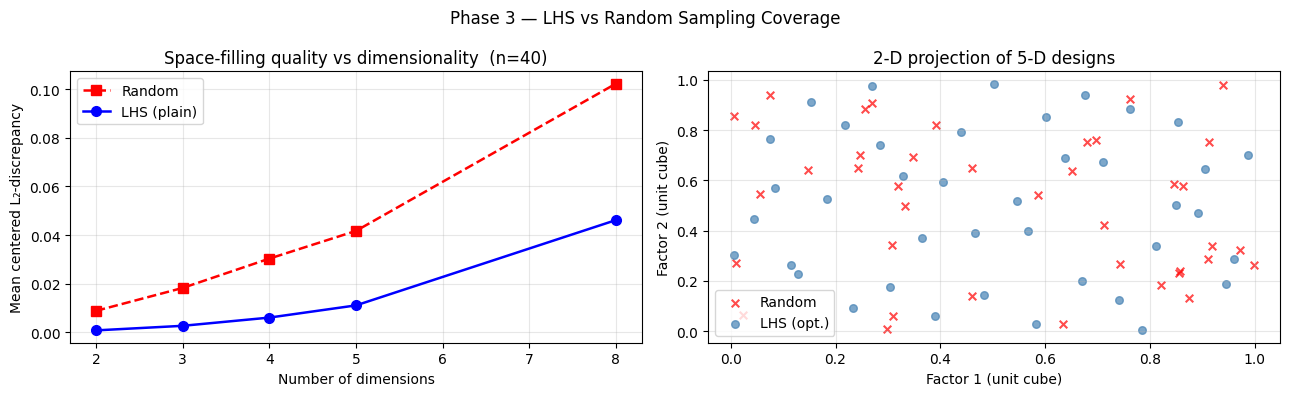

Discrepancy improvement (LHS/Random ratio):
  dim=2: random=0.0088  LHS=0.0008  ratio=10.8×
  dim=3: random=0.0183  LHS=0.0027  ratio=6.8×
  dim=4: random=0.0303  LHS=0.0061  ratio=5.0×
  dim=5: random=0.0417  LHS=0.0111  ratio=3.8×
  dim=8: random=0.1022  LHS=0.0461  ratio=2.2×


In [2]:
# ── Coverage comparison: LHS vs random vs full grid ───────────────────────────
rng_cov = make_rng(1)
n_samples  = 40
dimensions = [2, 3, 4, 5, 8]
n_reps     = 30

cd_random_list, cd_lhs_list = [], []

for d in dimensions:
    cd_rand_runs, cd_lhs_runs = [], []
    for rep in range(n_reps):
        # Random
        X_rand = rng_cov.random((n_samples, d))
        cd_rand_runs.append(qmc.discrepancy(X_rand))
        # LHS
        lhs_sampler = qmc.LatinHypercube(d=d, seed=rep, optimization=None)
        X_lhs = lhs_sampler.random(n_samples)
        cd_lhs_runs.append(qmc.discrepancy(X_lhs))
    cd_random_list.append(np.mean(cd_rand_runs))
    cd_lhs_list.append(np.mean(cd_lhs_runs))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: discrepancy vs dimensions
axes[0].plot(dimensions, cd_random_list, 'rs--', ms=7, lw=1.8, label='Random')
axes[0].plot(dimensions, cd_lhs_list,   'bo-',  ms=7, lw=1.8, label='LHS (plain)')
axes[0].set_xlabel('Number of dimensions')
axes[0].set_ylabel('Mean centered L₂-discrepancy')
axes[0].set_title(f'Space-filling quality vs dimensionality  (n={n_samples})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: 2-D scatter comparing LHS vs random (5D → show first 2)
d_demo = 5
X_rand_2d = rng_cov.random((n_samples, d_demo))
lhs_sampler_demo = qmc.LatinHypercube(d=d_demo, seed=0, optimization='random-cd')
X_lhs_2d = lhs_sampler_demo.random(n_samples)

axes[1].scatter(X_rand_2d[:,0], X_rand_2d[:,1], s=30, alpha=0.7, color='red',      label='Random', marker='x')
axes[1].scatter(X_lhs_2d[:,0],  X_lhs_2d[:,1],  s=30, alpha=0.7, color='steelblue', label='LHS (opt.)', marker='o')
axes[1].set_xlabel('Factor 1 (unit cube)')
axes[1].set_ylabel('Factor 2 (unit cube)')
axes[1].set_title('2-D projection of 5-D designs')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Phase 3 — LHS vs Random Sampling Coverage', fontsize=12)
plt.tight_layout()
plt.show()

print('Discrepancy improvement (LHS/Random ratio):')
for d, cr, cl in zip(dimensions, cd_random_list, cd_lhs_list):
    print(f'  dim={d}: random={cr:.4f}  LHS={cl:.4f}  ratio={cr/cl:.1f}×')

## 3.2  5-Factor LHS Design

### Sample-size guidelines

Two complementary rules determine a reasonable $n$:

1. **Model-based rule** ($n \geq 10d$): for $d = 5$ factors this gives $n \geq 50$ — enough data to fit a linear or Gaussian Process surrogate with reasonable leave-one-out cross-validation.
2. **Discrepancy convergence**: the CD of an optimised LHS scales roughly as $O(n^{-1})$, so doubling $n$ halves the discrepancy.  In practice $n = 60$–$100$ is sufficient for 5 dimensions.

We use $n = 60$ (12 points per factor on average), providing a small reserve for cross-validation without exhausting virtual-lab budget.

### Factor scaling

Each factor is mapped from its natural range $[X_i^{\text{low}},\, X_i^{\text{high}}]$ to the unit interval before sampling:

$$u_{ij} = \frac{X_{ij} - X_i^{\text{low}}}{X_i^{\text{high}} - X_i^{\text{low}}} \in [0, 1]$$

The LHS is generated entirely on $[0,1]^d$, then back-transformed to natural units for evaluation.  This separates the **sampling geometry** (unit cube) from the **physical model** (natural units), so the discrepancy metric is scale-free.

### Projection properties

A key guarantee of LHS is that every **1-D marginal projection** is uniform by construction — regardless of which factors the analyst later identifies as important.  This protects against two failure modes of random sampling:

- **Gaps** — an unlucky draw leaves a wide region of a key factor unexplored.
- **Clusters** — dense patches waste evaluations in a narrow region.

Two-factor projections are *approximately* (not exactly) uniform; optimisation with `random-cd` improves these.  This is why LHS is preferred over random sampling for preliminary screening: it guards against missing important regions of any single factor.

In [3]:
# ── Define 5 factors ──────────────────────────────────────────────────────────
FACTORS_5 = [
    Factor('tmp',        0.5,  2.0),
    Factor('crossflow',  0.5,  2.0),
    Factor('feed_conc',  2.0, 10.0),
    Factor('res_factor', 0.5,  2.0),   # × 5×10¹¹ /m
    Factor('sieving',   0.01,  0.15),
]

N_LHS    = 60
LHS_SEED = 0

# ── Generate the design ───────────────────────────────────────────────────────
design_lhs = latin_hypercube(FACTORS_5, n_samples=N_LHS, seed=LHS_SEED, optimization='random-cd')

metrics = coverage_metrics(design_lhs)
print(f'LHS design: {N_LHS} points × {len(FACTORS_5)} factors')
print(f'Centered L₂-discrepancy : {metrics["discrepancy"]:.6f}')
print(f'Min pairwise distance   : {metrics["min_pairwise_dist"]:.4f}')
print(f'Mean pairwise distance  : {metrics["mean_pairwise_dist"]:.4f}')
print()
print(design_lhs.describe().round(3))

LHS design: 60 points × 5 factors
Centered L₂-discrepancy : 0.002657
Min pairwise distance   : 0.2242
Mean pairwise distance  : 0.9073

          tmp  crossflow  feed_conc  res_factor  sieving
count  60.000     60.000     60.000      60.000   60.000
mean    1.249      1.250      5.989       1.249    0.080
std     0.436      0.436      2.327       0.438    0.041
min     0.520      0.520      2.003       0.513    0.010
25%     0.882      0.872      4.069       0.869    0.046
50%     1.249      1.249      5.957       1.247    0.080
75%     1.616      1.621      8.018       1.617    0.114
max     1.985      1.984      9.876       1.991    0.149


In [4]:
# ── Run the virtual lab at all LHS points ─────────────────────────────────────
NOISE = pert.NoiseModel(additive_sd=5e-4, proportional_cv=0.01)
CONC_FACTOR = 5.0
R_M_NOMINAL = 5e11   # 1/m

def evaluate_ufdf_5f(point: dict, seed: int = 0) -> dict:
    C0  = point['feed_conc']
    mem = MembraneProperties(
        area=0.05,
        hydraulic_resistance=R_M_NOMINAL * point['res_factor'],
        sieving_coefficient=point['sieving'],
    )
    cfg = UFDFConfig(
        membrane=mem,
        tmp=point['tmp'],
        crossflow_velocity=point['crossflow'],
        feed_concentration=C0,
        feed_volume=1.0,
        target_concentration=C0 * CONC_FACTOR,
        n_diavolumes=0.0,
    )
    t_eval = np.linspace(0, 7200, 400)
    res    = ufdf_sim(cfg, t_eval)
    C, t   = res['retentate_concentration'], res['t']

    reached   = C >= C0 * CONC_FACTOR * 0.99
    proc_time = float(t[reached][0]) if reached.any() else float(t[-1])

    idx = min(int(np.searchsorted(t, proc_time)), len(t)-1)
    mean_flux   = float(np.mean(res['flux'][:idx+1])) * 1e5 if idx > 0 else 0.0
    protein_yield = float(res['yield'][idx])

    # Analytical noise
    rng_ev = make_rng(seed)
    proc_time *= 1 + rng_ev.normal(0, 0.005)
    mean_flux  *= 1 + rng_ev.normal(0, 0.008)
    protein_yield = float(np.clip(protein_yield + rng_ev.normal(0, 5e-4), 0, 1))

    return {'proc_time': proc_time, 'mean_flux': mean_flux, 'protein_yield': protein_yield}

# ── Execute (each run is fast — RK45 on 400 points) ──────────────────────────
results_lhs = run_design(design_lhs, lambda pt: evaluate_ufdf_5f(pt, seed=int(pt['tmp']*100)))

print(f'Completed {len(results_lhs)} runs')
print()
for resp in ['proc_time','mean_flux','protein_yield']:
    print(f'{resp:16s}: {results_lhs[resp].min():.4f} – {results_lhs[resp].max():.4f}   '
          f'mean={results_lhs[resp].mean():.4f}')

Completed 60 runs

proc_time       : 90.1827 – 378.7497   mean=194.4836
mean_flux       : 4.2501 – 16.0191   mean=9.0019
protein_yield   : 0.7602 – 0.9862   mean=0.8811


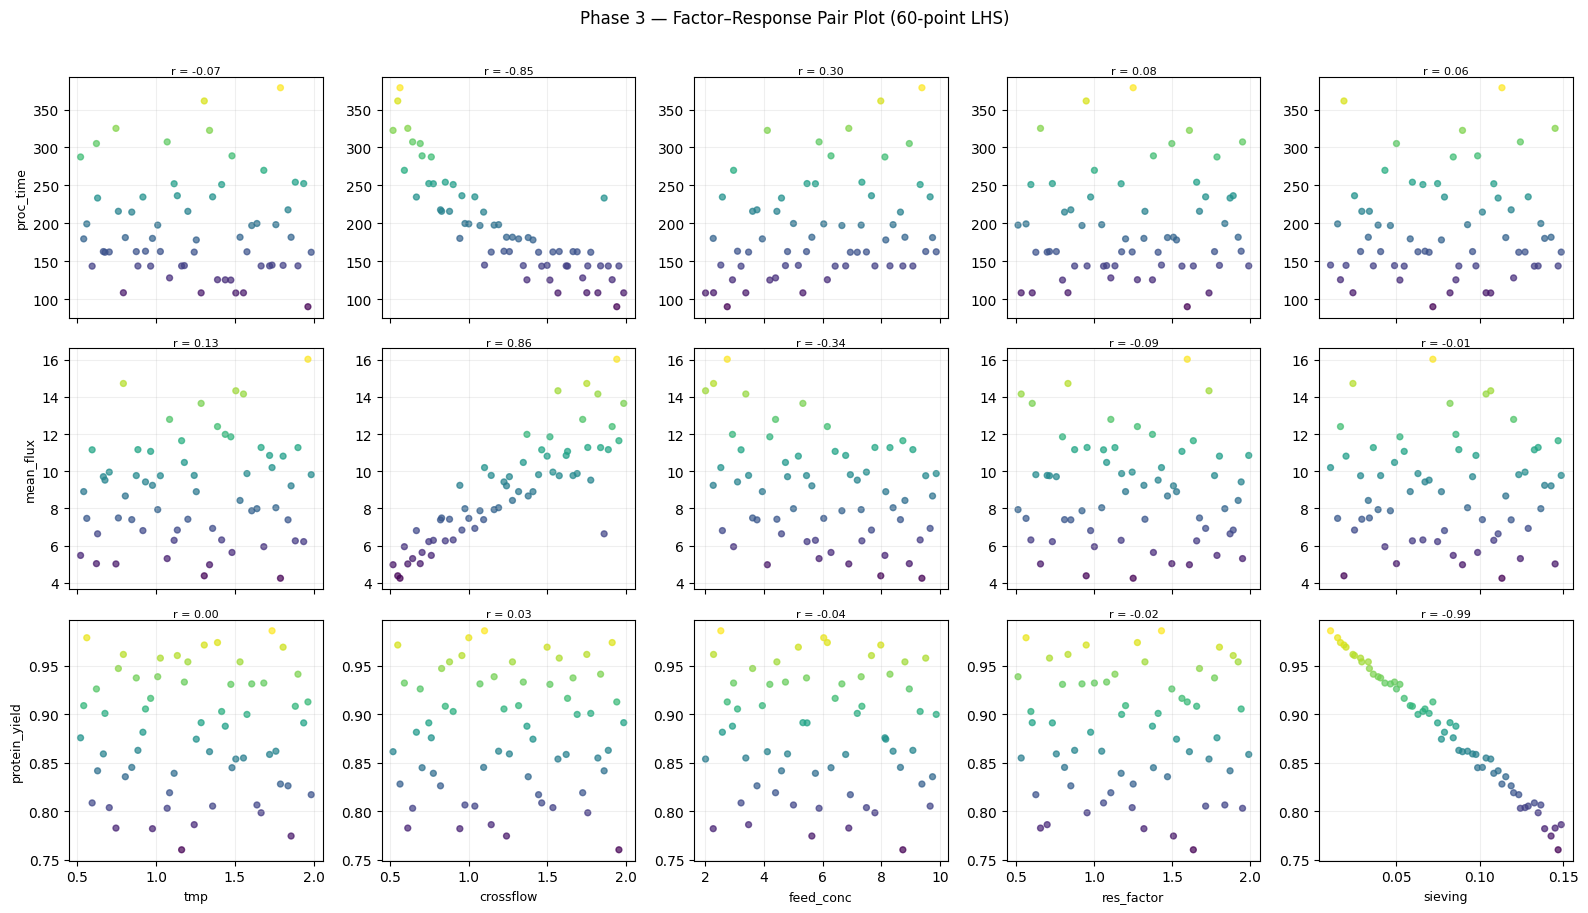

In [5]:
# ── Pair-plot (factors × responses) ──────────────────────────────────────────
factor_names5 = [f.name for f in FACTORS_5]
response_names = ['proc_time', 'mean_flux', 'protein_yield']

fig, axes = plt.subplots(len(response_names), len(factor_names5),
                          figsize=(16, 9), sharex='col')

for row_idx, resp in enumerate(response_names):
    for col_idx, fact in enumerate(factor_names5):
        ax = axes[row_idx, col_idx]
        sc = ax.scatter(results_lhs[fact], results_lhs[resp],
                        c=results_lhs[resp], cmap='viridis', s=18, alpha=0.7)
        # Correlation
        corr = results_lhs[[fact, resp]].corr().iloc[0,1]
        ax.set_title(f'r = {corr:.2f}', fontsize=8, pad=2)
        if row_idx == len(response_names) - 1:
            ax.set_xlabel(fact, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(resp, fontsize=9)
        ax.grid(alpha=0.2)

fig.suptitle('Phase 3 — Factor–Response Pair Plot (60-point LHS)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

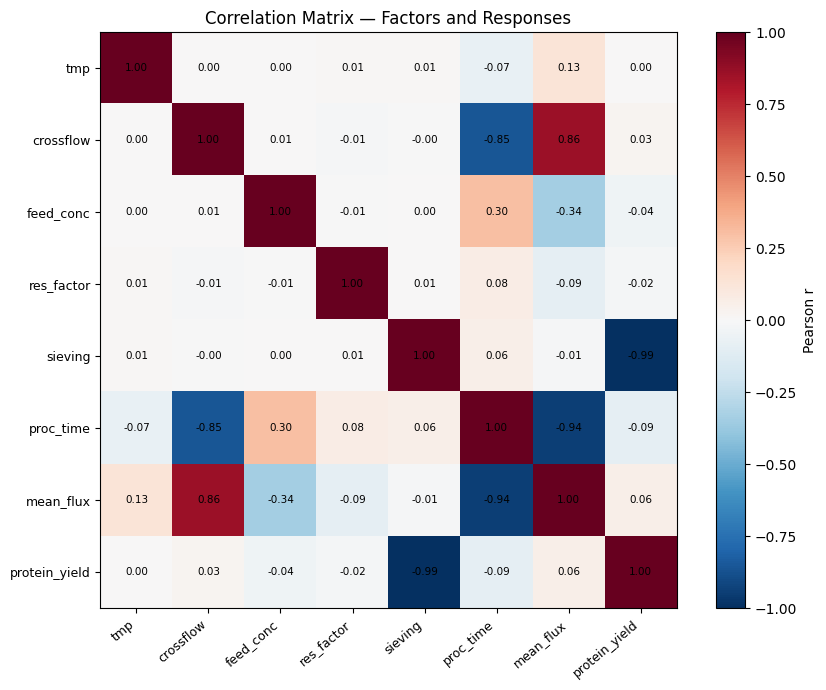

In [6]:
# ── Correlation matrix ─────────────────────────────────────────────────────────
corr_df = results_lhs[factor_names5 + response_names].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_df.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(corr_df)))
ax.set_yticks(range(len(corr_df)))
ax.set_xticklabels(corr_df.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(corr_df.columns, fontsize=9)
# Annotate with values
for i in range(len(corr_df)):
    for j in range(len(corr_df)):
        ax.text(j, i, f'{corr_df.values[i,j]:.2f}', ha='center', va='center', fontsize=7.5)
ax.set_title('Correlation Matrix — Factors and Responses')
plt.tight_layout()
plt.show()

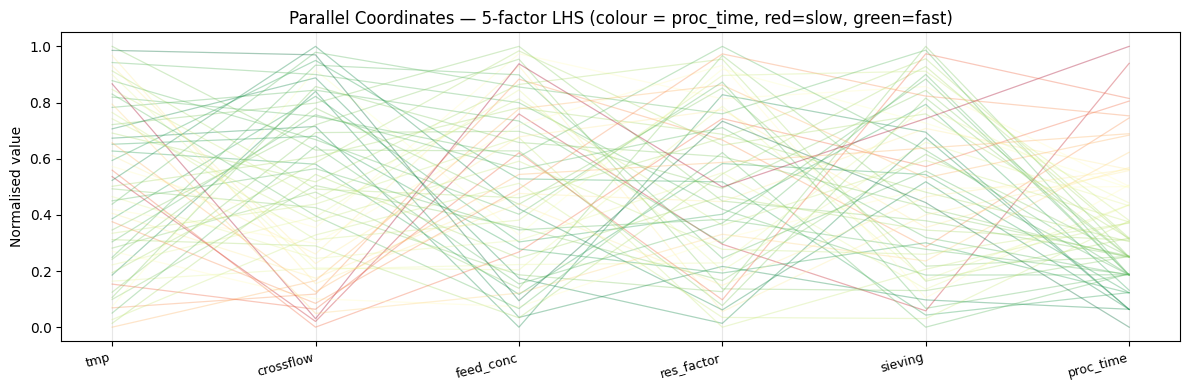

In [7]:
# ── Parallel coordinates plot ─────────────────────────────────────────────────
from matplotlib.path import Path
from matplotlib.patches import PathPatch

cols_to_plot = factor_names5 + ['proc_time']
df_norm = results_lhs[cols_to_plot].copy()
for c in cols_to_plot:
    lo, hi = df_norm[c].min(), df_norm[c].max()
    df_norm[c] = (df_norm[c] - lo) / (hi - lo + 1e-12)

fig, ax = plt.subplots(figsize=(12, 4))
n_axes = len(cols_to_plot)
cmap   = plt.cm.RdYlGn_r

for _, row in df_norm.iterrows():
    y = row[cols_to_plot].values
    x = np.arange(n_axes)
    # Colour by processing time (0=green=fast, 1=red=slow)
    color = cmap(float(row['proc_time']))
    ax.plot(x, y, color=color, alpha=0.35, lw=0.9)

ax.set_xticks(range(n_axes))
ax.set_xticklabels(cols_to_plot, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Normalised value')
ax.set_title('Parallel Coordinates — 5-factor LHS (colour = proc_time, red=slow, green=fast)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ── Save dataset for Phase 4 ──────────────────────────────────────────────────
path_lhs = PROCESSED_DATA_DIR / 'lhs_ufdf_5factor.csv'
results_lhs.to_csv(path_lhs)
print(f'Saved {len(results_lhs)}-row LHS dataset → {path_lhs}')
print(results_lhs.describe().round(4))

Saved 60-row LHS dataset → /home/ali/projects/DOE/data/processed/lhs_ufdf_5factor.csv
           tmp  crossflow  feed_conc  res_factor  sieving  proc_time  \
count  60.0000    60.0000    60.0000     60.0000  60.0000    60.0000   
mean    1.2490     1.2503     5.9892      1.2490   0.0799   194.4836   
std     0.4357     0.4361     2.3273      0.4375   0.0407    66.4352   
min     0.5204     0.5201     2.0026      0.5130   0.0104    90.1827   
25%     0.8821     0.8720     4.0690      0.8694   0.0455   144.0368   
50%     1.2488     1.2494     5.9571      1.2474   0.0805   179.8955   
75%     1.6157     1.6213     8.0182      1.6172   0.1139   234.7911   
max     1.9853     1.9845     9.8759      1.9909   0.1489   378.7497   

       mean_flux  protein_yield  
count    60.0000        60.0000  
mean      9.0019         0.8811  
std       2.7689         0.0615  
min       4.2501         0.7602  
25%       6.8323         0.8337  
50%       9.0621         0.8846  
75%      10.9043         0.

---
## 3.3  PCA — Dominant Variance Structure of the Design Space

### Mathematical formulation

PCA finds orthonormal directions $p_1, p_2, \ldots$ in (scaled) factor space that successively maximise the explained variance of $\mathbf{X}_s \in \mathbb{R}^{n \times p}$:

$$\mathbf{X}_s = \mathbf{T}\mathbf{P}^{\top} + \mathbf{E}, \qquad \mathbf{P}^{\top}\mathbf{P} = \mathbf{I}_A$$

- $\mathbf{T} = [t_1, \ldots, t_A]$ — **(scores)** $(n \times A)$: coordinates of each sample in PC space.  Captures *which samples* are similar or extreme.
- $\mathbf{P} = [p_1, \ldots, p_A]$ — **(loadings)** $(p \times A)$: unit-length directions in variable space.  Captures *which factors* co-vary.
- Columns of $\mathbf{P}$ are eigenvectors of the sample covariance matrix $\mathbf{X}_s^\top \mathbf{X}_s/(n-1)$, and $\mathbf{T} = \mathbf{X}_s \mathbf{P}$.

The variance fraction explained by PC$_a$ is $\lambda_a / \sum_{a'}\lambda_{a'}$, where $\lambda_a$ are the ordered eigenvalues.

### Biplot interpretation

A **biplot** overlays scores (sample positions) and loadings (variable arrows) on the same axes:
- Samples far from the origin along a loading arrow have large (positive or negative) values of that factor.
- Loading arrows pointing in similar directions indicate correlated factors; perpendicular arrows indicate independent factors.  For a well-optimised LHS (independent factors by construction), arrows should be roughly orthogonal.
- **Colouring samples by `proc_time`** reveals whether the response has a structured gradient in PC space — if the colour bands align with a loading arrow, that factor drives the response.

PCA is applied here to the **5 process factors only** (responses excluded) to check for unintended collinearity in the LHS design and to identify which factor combinations explain most variance across the 60 runs.

PC   Var. explained   Cumulative
──────────────────────────────────────
PC1        20.4%          20.4%
PC2        20.2%          40.6%
PC3        19.9%          60.5%
PC4        19.8%          80.3%
PC5        19.7%         100.0%


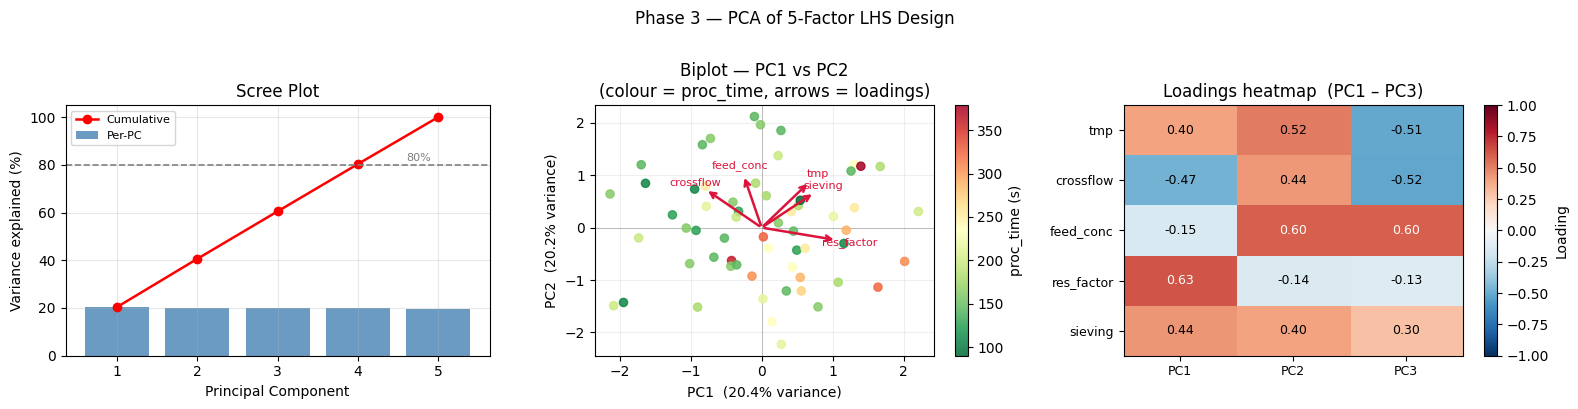

In [9]:
# ── PCA on the 5-factor LHS design ────────────────────────────────────────────
from downstream_doe.doe.multivariate import pca_analysis

pca = pca_analysis(results_lhs, factor_names5, n_components=5)

print('PC   Var. explained   Cumulative')
print('─' * 38)
for a, (evr, cum) in enumerate(zip(pca.explained_variance_ratio, pca.cumulative_variance)):
    print(f'PC{a+1}       {evr*100:5.1f}%         {cum*100:5.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scree plot
ax = axes[0]
pc_idx = np.arange(1, 6)
ax.bar(pc_idx, pca.explained_variance_ratio * 100, color='steelblue', alpha=0.8, label='Per-PC')
ax.plot(pc_idx, pca.cumulative_variance * 100, 'ro-', lw=1.8, ms=6, label='Cumulative')
ax.axhline(80, ls='--', color='gray', lw=1.2)
ax.text(4.6, 81.5, '80%', fontsize=8, color='gray')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree Plot')
ax.set_xticks(pc_idx)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Biplot: PC1 vs PC2, colour = proc_time
ax = axes[1]
sc = ax.scatter(pca.scores[:, 0], pca.scores[:, 1],
                c=results_lhs['proc_time'], cmap='RdYlGn_r', s=35, alpha=0.85, zorder=3)
plt.colorbar(sc, ax=ax, label='proc_time (s)')
arrow_scale = np.abs(pca.scores[:, :2]).max() * 0.75
for i, name in enumerate(factor_names5):
    lx = pca.loadings[i, 0] * arrow_scale
    ly = pca.loadings[i, 1] * arrow_scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
    ax.text(lx * 1.18, ly * 1.18, name, fontsize=8, color='crimson', ha='center', va='center')
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio[1]*100:.1f}% variance)')
ax.set_title('Biplot — PC1 vs PC2\n(colour = proc_time, arrows = loadings)')
ax.grid(alpha=0.2)

# Loading heatmap: PC1–PC3
ax = axes[2]
load_vals = pca.loadings[:, :3]
im = ax.imshow(load_vals, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Loading')
ax.set_xticks(range(3))
ax.set_xticklabels([f'PC{i+1}' for i in range(3)], fontsize=9)
ax.set_yticks(range(5))
ax.set_yticklabels(factor_names5, fontsize=9)
for i in range(5):
    for j in range(3):
        v = load_vals[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.55 else 'black')
ax.set_title('Loadings heatmap  (PC1 – PC3)')

fig.suptitle('Phase 3 — PCA of 5-Factor LHS Design', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 3.4  PLS — Predicting CQAs from Process Factors

### What PLS does differently from PCA

PLS simultaneously decomposes **X** (factors) and **Y** (responses) to find latent variables that maximise the **covariance** between the two blocks:

$$\max_{w,\,c}\; \text{Cov}(\mathbf{X}w,\, \mathbf{Y}c) \quad \text{s.t.}\; \|w\| = \|c\| = 1$$

$$\mathbf{X}_s = \mathbf{T}\mathbf{P}^{\top} + \mathbf{E}, \qquad \mathbf{Y}_s = \mathbf{T}\mathbf{Q}^{\top} + \mathbf{F}$$

The shared score matrix $\mathbf{T}$ identifies directions in factor space that are both self-consistent (capture X-variance) and predictive (correlated with Y).  A factor that explains much X-variance but is uncorrelated with Y receives small PLS weight $w_j$ — this is why PLS is preferred over PCA for regression when not all factor variance is response-relevant.

The NIPALS algorithm extracts one latent variable (LV) at a time by iterating $t_a \leftarrow Xw_a / \|w_a\|$, $u_a \leftarrow Yc_a / \|c_a\|$, $w_a \leftarrow X^{\top}u_a$, $c_a \leftarrow Y^{\top}t_a$ until convergence, then deflating both X and Y before the next LV.

### VIP scores — ranking factor importance

The **Variable Importance in Projection** summarises each factor's contribution to predicting $\mathbf{Y}$ across all latent variables, weighted by how much Y-variance each LV captures:

$$\text{VIP}_j = \sqrt{p \sum_{a=1}^{A} \frac{SS_a}{\sum_{a'}SS_{a'}} \cdot \frac{w_{ja}^2}{\|w_a\|^2}}, \qquad SS_a = \mathbf{t}_a^\top\mathbf{t}_a \cdot \mathbf{q}_a^\top\mathbf{q}_a$$

By convention, $\text{VIP}_j > 1$ means the factor contributes above its proportional share to predicting all responses — a practical criterion for identifying key CPPs without running separate univariate regressions.

### Model quality metrics

| Metric | Formula | Interpretation |
|---|---|---|
| $R^2X_{\text{cum}}$ | $1 - \|E_A\|_F^2 / \|X_s\|_F^2$ | X-block variance explained (in-sample) |
| $R^2Y_{\text{cum}}$ | $1 - \|F_A\|_F^2 / \|Y_s\|_F^2$ | Response variance explained (in-sample) |
| $Q^2$ | cross-val $R^2Y$ | Predictive ability; $Q^2 > 0.5$ → useful model |

$Q^2 < R^2Y$ always; the gap $R^2Y - Q^2$ measures over-fitting.

PLS diagnostics:
  R²X cumulative : ['0.200', '0.400', '0.599']
  R²Y cumulative : ['0.574', '0.899', '0.900']
  Q²  (5-fold CV): 0.770

Factor           VIP
──────────────────────
crossflow      1.647  ← key CPP
sieving        1.355  ← key CPP
feed_conc      0.622
tmp            0.198
res_factor     0.162


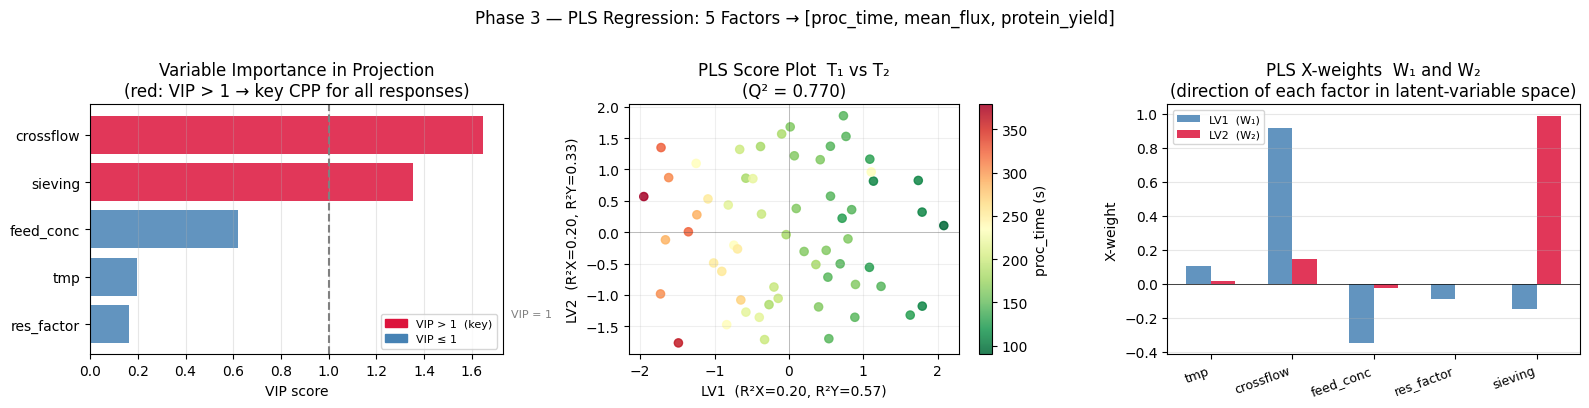

In [10]:
# ── PLS: 5 factors → 3 responses ─────────────────────────────────────────────
from downstream_doe.doe.multivariate import pls_analysis

pls = pls_analysis(
    results_lhs, factor_names5, response_names,
    n_components=3, cv_folds=5,
)

print('PLS diagnostics:')
print(f'  R²X cumulative : {[f"{v:.3f}" for v in pls.r2_x]}')
print(f'  R²Y cumulative : {[f"{v:.3f}" for v in pls.r2_y]}')
print(f'  Q²  (5-fold CV): {pls.q2:.3f}')
print()
print(f'{"Factor":12s}  {"VIP":>6}')
print('─' * 22)
for name, vip in sorted(zip(pls.feature_names, pls.vip_scores), key=lambda x: -x[1]):
    flag = '  ← key CPP' if vip > 1 else ''
    print(f'{name:12s}  {vip:6.3f}{flag}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# VIP bar chart
ax = axes[0]
order = np.argsort(pls.vip_scores)
colors_vip = ['crimson' if v > 1 else 'steelblue' for v in pls.vip_scores[order]]
ax.barh([factor_names5[i] for i in order], pls.vip_scores[order], color=colors_vip, alpha=0.85)
ax.axvline(1.0, ls='--', color='gray', lw=1.5)
ax.text(1.02, 0.15, 'VIP = 1', fontsize=8, color='gray', transform=ax.get_yaxis_transform())
ax.set_xlabel('VIP score')
ax.set_title('Variable Importance in Projection\n(red: VIP > 1 → key CPP for all responses)')
ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='crimson', label='VIP > 1  (key)'),
                    Patch(color='steelblue', label='VIP ≤ 1')], fontsize=8, loc='lower right')

# Score plot T₁ vs T₂, colour = proc_time
ax = axes[1]
sc = ax.scatter(pls.x_scores[:, 0], pls.x_scores[:, 1],
                c=results_lhs['proc_time'], cmap='RdYlGn_r', s=35, alpha=0.85)
plt.colorbar(sc, ax=ax, label='proc_time (s)')
ax.set_xlabel(f'LV1  (R²X={pls.r2_x[0]:.2f}, R²Y={pls.r2_y[0]:.2f})')
ax.set_ylabel(f'LV2  (R²X={pls.r2_x[1]-pls.r2_x[0]:.2f}, R²Y={pls.r2_y[1]-pls.r2_y[0]:.2f})')
ax.set_title(f'PLS Score Plot  T₁ vs T₂\n(Q² = {pls.q2:.3f})')
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)
ax.grid(alpha=0.2)

# X-weights for LV1 and LV2
ax = axes[2]
x_pos = np.arange(len(factor_names5))
w = 0.3
ax.bar(x_pos - w/2, pls.x_weights[:, 0], w, label='LV1  (W₁)', color='steelblue', alpha=0.85)
ax.bar(x_pos + w/2, pls.x_weights[:, 1], w, label='LV2  (W₂)', color='crimson',   alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(factor_names5, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('X-weight')
ax.set_title('PLS X-weights  W₁ and W₂\n(direction of each factor in latent-variable space)')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Phase 3 — PLS Regression: 5 Factors → [proc_time, mean_flux, protein_yield]',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Phase 3 Summary

**LHS efficiency vs full grid:**
- A $5^5 = 3125$-point grid would be needed for 5 levels per factor in 5 dimensions.
- Our 60-point LHS achieves low discrepancy (near-uniform coverage) with 52× fewer runs.
- The pair-plot confirms the two dominant drivers: **cross-flow** (negative correlation with processing time) and **sieving** (negative correlation with protein yield).

**PCA — design space structure:**
- Because the LHS factors are independently sampled, the scree plot shows approximately equal variance (~20%) per PC — confirming no unintended collinearity in the design.
- The biplot reveals that `proc_time` gradients align most strongly with the crossflow and feed_conc loading arrows (PC1), while `sieving` loads independently onto PC2 — consistent with its exclusive influence on protein yield.

**PLS — CPP importance ranking:**
- **Cross-flow** and **feed_conc** emerge with VIP > 1 for processing time and flux — consistent with the gel-polarisation physics (crossflow sweeps the concentration-polarisation layer; feed_conc determines its thickness).
- **Sieving coefficient** dominates protein yield — the primary membrane selection criterion, independent of operating conditions.
- $Q^2 > 0$ (cross-validated) confirms the PLS model has genuine predictive ability beyond just in-sample fit.

**Design-space observations:**
1. Cross-flow velocity is the dominant driver of processing time — consistent with the Phase 2 factorial result.
2. Sieving coefficient dominates protein yield — a membrane selection criterion.
3. TMP × cross-flow interaction is visible in the pair-plot cluster structure.

**Next step:** Phase 4 will train a GP surrogate on this dataset and use it to find the operating point that minimises processing time while keeping protein yield above a target.

---
*Dataset saved to `data/processed/lhs_ufdf_5factor.csv`.*